# Подготовка данных

### исходный датасет: data_for_weka_aw.csv

## Входные данные  

'Unnamed: 0' - мусор

'age' - возраст (int)   
'gender' - пол (labelencoder: либо 1 муж. 0 жен. либо наоборот)   
'height' - рост (float)   
'weight' - вес (float)  

### Данные с датчиков  

'Applewatch.Steps_LE' - агрегированные шаги за минуту    
'Applewatch.Heart_LE' - агрегированный пульс за минуту  
'Applewatch.Calories_LE' - агрегированные каллории за минуту  
'Applewatch.Distance_LE' - агрегированная дистанция за мунуту

### Вычисляемые данные

'EntropyApplewatchHeartPerDay_LE' - Энтропия всех измерений пульса и шагов за день
'EntropyApplewatchStepsPerDay_LE'

'RestingApplewatchHeartrate_LE' - Пульс покоя для каждого человека индивидуально    
'CorrelationApplewatchHeartrateSteps_LE' - Кореляция пульса с шагами    
'NormalizedApplewatchHeartrate_LE' - нормалированный пульс по формуле Пульс - пульс покоя  
'ApplewatchIntensity_LE' - Формула интенсивности от пульса и шагов (выведена ниже)  
'SDNormalizedApplewatchHR_LE',  
'ApplewatchStepsXDistance_LE' - произведение Шаги * дистанцию за минуту  

### Целевая переменная

'activity_trimmed' - класс активности: Сидеть, Лежать, Идти на месте, Бег 3-4-7   





In [8]:
df = pd.read_csv("data_for_weka_aw.csv")
df = df.drop("Unnamed: 0", axis=1)

# Пайплайн получения данных из сырых

In [7]:
import pandas as pd
import numpy as np
from typing import Dict, Optional, List
import warnings
warnings.filterwarnings('ignore')


class AppleWatchSyntheticFeatures:
    """
    Пайплайн создания синтетических признаков из уже агрегированных данных Apple Watch

    Входные данные (обязательные):
    - age, gender, height, weight
    - Applewatch.Steps_LE, Applewatch.Heart_LE, Applewatch.Calories_LE, Applewatch.Distance_LE
    - RestingApplewatchHeartrate_LE
    - EntropyApplewatchHeartPerDay_LE, EntropyApplewatchStepsPerDay_LE (опционально)

    Выходные данные (создаются):
    - NormalizedApplewatchHeartrate_LE
    - SDNormalizedApplewatchHR_LE
    - ApplewatchIntensity_LE
    - CorrelationApplewatchHeartrateSteps_LE
    - ApplewatchStepsXDistance_LE
    """

    def __init__(
        self,
        intensity_params: Optional[Dict] = None,
        sd_normalized_span: int = 3,
        correlation_window: int = 30
    ):
        """
        Parameters
        ----------
        intensity_params : dict, optional
            Параметры расчёта интенсивности. По умолчанию используются оптимизированные:
            {'weight_hr': 0.90, 'hr_max': 80, 'steps_max': 50, 'scale': 0.791, 'offset': -0.079}

        sd_normalized_span : int
            Параметр span для EWM std при расчёте SDNormalized (по умолчанию 3)

        correlation_window : int
            Размер скользящего окна для корреляции пульс-шаги (по умолчанию 30 минут)
        """
        self.intensity_params = intensity_params or {
            'weight_hr': 0.90,
            'hr_max': 80,
            'steps_max': 50,
            'scale': 0.791,
            'offset': -0.079
        }
        self.sd_normalized_span = sd_normalized_span
        self.correlation_window = correlation_window
        self._fitted = False

    # FIT: проверка данных и вычисление глобальных статистик

    def fit(self, df: pd.DataFrame) -> 'AppleWatchSyntheticFeatures':
        """
        Проверка входных данных и подготовка к трансформации

        Parameters
        ----------
        df : pd.DataFrame
            Датафрейм с уже агрегированными признаками
        """
        # Обязательные колонки
        required_cols = [
            'age', 'gender', 'height', 'weight',
            'Applewatch.Steps_LE',
            'Applewatch.Heart_LE',
            'Applewatch.Calories_LE',
            'Applewatch.Distance_LE',
            'RestingApplewatchHeartrate_LE'
        ]

        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Отсутствуют обязательные колонки: {missing_cols}")

        # Проверка на пропуски
        critical_cols = ['Applewatch.Heart_LE', 'RestingApplewatchHeartrate_LE', 'Applewatch.Steps_LE']
        for col in critical_cols:
            if df[col].isna().all():
                raise ValueError(f"Колонка {col} полностью состоит из пропусков")

        # Глобальные статистики
        self._global_stats = {
            'heart_mean': df['Applewatch.Heart_LE'].mean(),
            'heart_std': df['Applewatch.Heart_LE'].std(),
            'steps_mean': df['Applewatch.Steps_LE'].mean(),
            'steps_std': df['Applewatch.Steps_LE'].std(),
        }

        self._fitted = True
        return self

    # TRANSFORM: создание всех синтетических признаков

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Создание синтетических признаков на основе агрегированных данных

        Parameters
        ----------
        df : pd.DataFrame
            Датафрейм с уже агрегированными признаками

        Returns
        -------
        pd.DataFrame
            Датафрейм с добавленными синтетическими признаками
        """
        if not self._fitted:
            raise RuntimeError("Call fit() before transform()")

        # Копируем, чтобы не модифицировать исходный датафрейм
        features = df.copy()

        # 1. NormalizedApplewatchHeartrate_LE: дельта от resting HR
        features['NormalizedApplewatchHeartrate_LE'] = (
            features['Applewatch.Heart_LE'] - features['RestingApplewatchHeartrate_LE']
        )

        # 2. SDNormalizedApplewatchHR_LE: EWM std от нормализованного пульса
        # АППРОКСИМАЦИЯ (оригинал не восстановлен)
        features['SDNormalizedApplewatchHR_LE'] = (
            features['NormalizedApplewatchHeartrate_LE']
            .ewm(span=self.sd_normalized_span, min_periods=2)
            .std()
            .fillna(0)
        )

        # 3. ApplewatchIntensity_LE: оптимизированная линейная комбинация
        features['ApplewatchIntensity_LE'] = self._calculate_intensity(features)

        # 4. CorrelationApplewatchHeartrateSteps_LE: rolling Pearson correlation
        features['CorrelationApplewatchHeartrateSteps_LE'] = self._rolling_pearson(
            features['Applewatch.Heart_LE'],
            features['Applewatch.Steps_LE'],
            window=self.correlation_window
        )

        # 5. ApplewatchStepsXDistance_LE: интерактивный признак
        features['ApplewatchStepsXDistance_LE'] = (
            features['Applewatch.Steps_LE'] * features['Applewatch.Distance_LE']
        )

        # 6. ОЧИСТКА ДАННЫХ

        # Замена inf/-inf на NaN
        features = features.replace([np.inf, -np.inf], np.nan)

        # Заполнение пропусков: forward-fill + backward-fill + 0
        features = features.ffill().bfill().fillna(0)

        return features

    # ВСПОМОГАТЕЛЬНЫЕ МЕТОДЫ

    def _calculate_intensity(self, features: pd.DataFrame) -> pd.Series:
        """
        Расчёт интенсивности активности

        Формула: 0.9 * norm(ΔHR) + 0.1 * norm(log(Steps)) → scale + offset
        """
        p = self.intensity_params

        # Дельта пульса (только положительные отклонения)
        hr_delta = features['NormalizedApplewatchHeartrate_LE'].clip(0)

        # Логарифм шагов
        steps_log = np.log1p(features['Applewatch.Steps_LE'])

        # Нормализация компонентов в [0, 1]
        hr_norm = (hr_delta / p['hr_max']).clip(0, 1)
        steps_norm = (steps_log / np.log1p(p['steps_max'])).clip(0, 1)

        # Линейная комбинация (90% пульс, 10% шаги)
        intensity_raw = p['weight_hr'] * hr_norm + (1 - p['weight_hr']) * steps_norm

        # Пост-обработка: масштабирование + сдвиг + клиппинг
        intensity = (intensity_raw * p['scale'] + p['offset']).clip(0, 1)

        return intensity

    @staticmethod
    def _rolling_pearson(x: pd.Series, y: pd.Series, window: int = 30) -> pd.Series:
        """
        Скользящая корреляция Пирсона

        Parameters
        ----------
        x, y : pd.Series
            Временные ряды для расчёта корреляции (должны быть в хронологическом порядке!)
        window : int
            Размер скользящего окна (в количестве строк/минут)
        """
        result = []
        for i in range(len(x)):
            wx = x.iloc[max(0, i - window):i + 1]
            wy = y.iloc[max(0, i - window):i + 1]

            # Проверка на достаточную вариативность
            if wx.std() < 1e-6 or wy.std() < 1e-6 or len(wx.dropna()) < 10:
                result.append(1.0)  # дефолт при отсутствии вариации
            else:
                corr = wx.corr(wy)
                result.append(corr if not np.isnan(corr) else 1.0)

        return pd.Series(result, index=x.index).ffill().bfill()

    # ДОП МЕТОДЫ

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Удобный метод: fit + transform"""
        return self.fit(df).transform(df)

    def get_feature_names(self) -> List[str]:
        """Возвращает список всех признаков (входные + созданные)"""
        return [
            # Входные (демография)
            'age', 'gender', 'height', 'weight',
            # Входные (базовые _LE)
            'Applewatch.Steps_LE',
            'Applewatch.Heart_LE',
            'Applewatch.Calories_LE',
            'Applewatch.Distance_LE',
            'RestingApplewatchHeartrate_LE',
            'EntropyApplewatchHeartPerDay_LE',
            'EntropyApplewatchStepsPerDay_LE',
            # Создаваемые (синтетические)
            'NormalizedApplewatchHeartrate_LE',
            'SDNormalizedApplewatchHR_LE',
            'ApplewatchIntensity_LE',
            'CorrelationApplewatchHeartrateSteps_LE',
            'ApplewatchStepsXDistance_LE',
        ]

    def get_created_features(self) -> List[str]:
        """Возвращает список только созданных признаков"""
        return [
            'NormalizedApplewatchHeartrate_LE',
            'SDNormalizedApplewatchHR_LE',
            'ApplewatchIntensity_LE',
            'CorrelationApplewatchHeartrateSteps_LE',
            'ApplewatchStepsXDistance_LE',
        ]

    def get_feature_summary(self) -> pd.DataFrame:
        """Возвращает таблицу с описанием всех признаков"""
        summary = pd.DataFrame({
            'Признак': self.get_feature_names(),
            'Категория': [
                'демография', 'демография', 'демография', 'демография',
                'базовый', 'базовый', 'базовый', 'базовый',
                'базовый', 'базовый', 'базовый',
                'синтетический', 'синтетический', 'синтетический',
                'синтетический', 'синтетический'
            ],
            'Описание': [
                'Возраст пользователя',
                'Пол (0/1)',
                'Рост (см)',
                'Вес (кг)',
                'Шаги за минуту',
                'Пульс (bpm), среднее за минуту',
                'Калории за минуту',
                'Дистанция за минуту (км)',
                'Пульс покоя (bpm)',
                'Энтропия пульса (окно 1 день)',
                'Энтропия шагов (окно 1 день)',
                'Дельта пульса от resting',
                'Вариабельность пульса (EWM std, span=3)',
                'Интенсивность активности [0, 1]',
                'Корреляция пульс-шаги (окно 30 мин)',
                'Шаги × Дистанция',
            ]
        })
        return summary

In [9]:
pipeline = AppleWatchSyntheticFeatures(
    intensity_params=None,          # None = использовать оптимизированные
    sd_normalized_span=3,
    correlation_window=30
)

features = pipeline.fit_transform(df)

In [11]:
df.head()

,age,gender,height,weight,Applewatch.Steps_LE,Applewatch.Heart_LE,Applewatch.Calories_LE,Applewatch.Distance_LE,EntropyApplewatchHeartPerDay_LE,EntropyApplewatchStepsPerDay_LE,RestingApplewatchHeartrate_LE,CorrelationApplewatchHeartrateSteps_LE,NormalizedApplewatchHeartrate_LE,ApplewatchIntensity_LE,SDNormalizedApplewatchHR_LE,ApplewatchStepsXDistance_LE,activity_trimmed
0,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,19.531302,0.138520,1.000000,0.089692,Lying
1,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,19.453390,0.137967,1.000000,0.102088,Lying
2,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,19.540825,0.138587,1.000000,0.115287,Lying
3,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,19.628260,0.139208,1.000000,0.129286,Lying
4,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,19.715695,0.139828,0.241567,0.144088,Lying


In [10]:
features.head()

,age,gender,height,weight,Applewatch.Steps_LE,Applewatch.Heart_LE,Applewatch.Calories_LE,Applewatch.Distance_LE,EntropyApplewatchHeartPerDay_LE,EntropyApplewatchStepsPerDay_LE,RestingApplewatchHeartrate_LE,CorrelationApplewatchHeartrateSteps_LE,NormalizedApplewatchHeartrate_LE,ApplewatchIntensity_LE,SDNormalizedApplewatchHR_LE,ApplewatchStepsXDistance_LE,activity_trimmed
0,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.0,19.531302,0.144408,0.000000,0.089692,Lying
1,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.0,19.453390,0.144883,0.055092,0.102088,Lying
2,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.0,19.540825,0.146766,0.051291,0.115287,Lying
3,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.0,19.628260,0.148591,0.079407,0.129286,Lying
4,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,1.0,19.715695,0.150364,0.102895,0.144088,Lying


# Предобработка входных данных (с уже подготовленными синтетическими признаками)

In [28]:
class ActivityDataPreprocessor:
    """
    Препроцессор для данных активности Harvard
    """

    def __init__(self, target_col: str = 'activity_trimmed'):
        self.target_col = target_col
        self.scaler = StandardScaler()
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        self.numeric_features = []
        self.categorical_features = []
        self.feature_names = []
        self.target_mapping = {}
        self.is_fitted = False

    def identify_features(self, df: pd.DataFrame) -> None:
        """Автоматическое определение типов признаков"""
        exclude_cols = [self.target_col, 'Unnamed: 0']

        self.numeric_features = [
            col for col in df.select_dtypes(include=[np.number]).columns
            if col not in exclude_cols
        ]

        self.categorical_features = [
            col for col in df.select_dtypes(include=['object', 'category']).columns
            if col not in exclude_cols
        ]

        print(f"Найдено числовых признаков: {len(self.numeric_features)}")
        print(f"Найдено категориальных признаков: {len(self.categorical_features)}")

    def encode_target(self, df: pd.DataFrame) -> pd.Series:
        """Кодирование целевой переменной (activity → int)"""
        unique_classes = sorted(df[self.target_col].unique())
        self.target_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
        self.inverse_target_mapping = {idx: cls for cls, idx in self.target_mapping.items()}

        y = df[self.target_col].map(self.target_mapping)
        print(f"Классы активности: {self.target_mapping}")
        return y

    def fit_transform(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """Обучение препроцессора и трансформация данных"""
        self.identify_features(df)
        y = self.encode_target(df)

        # Обработка числовых признаков
        X_numeric = df[self.numeric_features].copy()
        # Заполнение пропусков медианой
        X_numeric = X_numeric.fillna(X_numeric.median())
        X_numeric_scaled = self.scaler.fit_transform(X_numeric)

        # Обработка категориальных признаков
        if self.categorical_features:
            X_categorical = df[self.categorical_features].copy()
            X_categorical = X_categorical.fillna('Unknown')
            X_categorical_encoded = self.encoder.fit_transform(X_categorical)
            cat_feature_names = self.encoder.get_feature_names_out(self.categorical_features)
            self.feature_names = self.numeric_features + list(cat_feature_names)
            X = np.hstack([X_numeric_scaled, X_categorical_encoded])
        else:
            self.feature_names = self.numeric_features
            X = X_numeric_scaled

        self.is_fitted = True
        print(f"Данные подготовлены. Итоговая матрица: {X.shape}")
        return X, y.values

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """Трансформация новых данных (для инференса)"""
        if not self.is_fitted:
            raise ValueError("Препроцессор не обучен! Вызовите fit_transform сначала.")

        X_numeric = df[self.numeric_features].fillna(0)
        X_numeric_scaled = self.scaler.transform(X_numeric)

        if self.categorical_features:
            X_categorical = df[self.categorical_features].fillna('Unknown')
            X_categorical_encoded = self.encoder.transform(X_categorical)
            X = np.hstack([X_numeric_scaled, X_categorical_encoded])
        else:
            X = X_numeric_scaled

        return X

    def inverse_transform_target(self, y: np.ndarray) -> list:
        """Возврат названий активностей из предсказаний модели"""
        return [self.inverse_target_mapping.get(idx, 'Unknown') for idx in y]

    def save(self, path: str = 'models/preprocessor.joblib') -> None:
        """Сохранение состояния (для локального использования в приложении)"""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump(self, path)
        print(f"Препроцессор сохранён: {path}")

    @staticmethod
    def load(path: str) -> 'ActivityDataPreprocessor':
        """Загрузка сохранённого препроцессора"""
        return joblib.load(path)

In [29]:
preprocessor = ActivityDataPreprocessor()
X, y = preprocessor.fit_transform(features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}, Test set: {X_test.shape}")

preprocessor.save('models/preprocessor_v1.joblib')

loaded_prep = ActivityDataPreprocessor.load('models/preprocessor_v1.joblib')
X_test_check = loaded_prep

Найдено числовых признаков: 16
Найдено категориальных признаков: 0
Классы активности: {'Lying': 0, 'Running 3 METs': 1, 'Running 5 METs': 2, 'Running 7 METs': 3, 'Self Pace walk': 4, 'Sitting': 5}
Данные подготовлены. Итоговая матрица: (3656, 16)

Train set: (3290, 16), Test set: (366, 16)
Препроцессор сохранён: models/preprocessor_v1.joblib


# Обучение xgboost

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import joblib
import os
from typing import Tuple, Dict, Optional

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import xgboost as xgb

import warnings

In [18]:
best_params = {
    'n_estimators': 412,
    'max_depth': 7,
    'learning_rate': 0.05259189873268501,
    'subsample': 0.6273436115554192,
    'colsample_bytree': 0.8601696737189636,
    'min_child_weight': 1,
    'gamma': 0.03924923021690026,
    'reg_alpha': 0.03073470465028678,
    'reg_lambda': 0.9428595026044732,
    'scale_pos_weight': 1.7662945534315597
    }


Train: (3290, 16) | Test: (366, 16)
Классы: {0: 'Lying', 1: 'Running 3 METs', 2: 'Running 5 METs', 3: 'Running 7 METs', 4: 'Self Pace walk', 5: 'Sitting'}

Оценка качества...

МЕТРИКИ КАЧЕСТВА
Accuracy                  | Train: 0.9997 | Test: 0.8361
Precision (macro)         | Train: 0.9997 | Test: 0.8350
Recall (macro)            | Train: 0.9998 | Test: 0.8349
F1 (macro)                | Train: 0.9997 | Test: 0.8343

Cross-Validation F1: 0.8410 (+/- 0.0396)

Classification Report (Test):
                precision    recall  f1-score   support

         Lying       0.79      0.80      0.79        79
Running 3 METs       0.84      0.89      0.86        57
Running 5 METs       0.87      0.92      0.89        60
Running 7 METs       0.95      0.94      0.94        62
Self Pace walk       0.81      0.79      0.80        53
       Sitting       0.76      0.67      0.71        55

      accuracy                           0.84       366
     macro avg       0.84      0.83      0.83       366


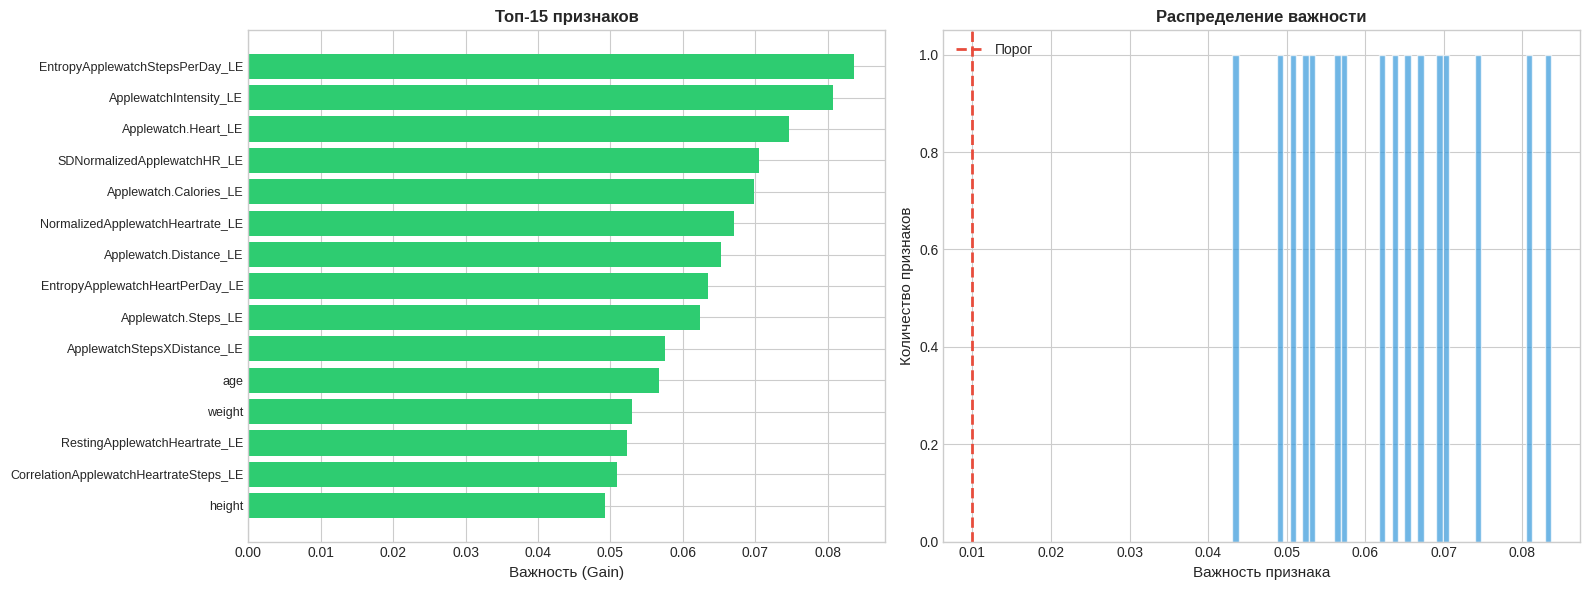

Матрица сохранена: experiments/xgboost_optuna/confusion_matrix.png


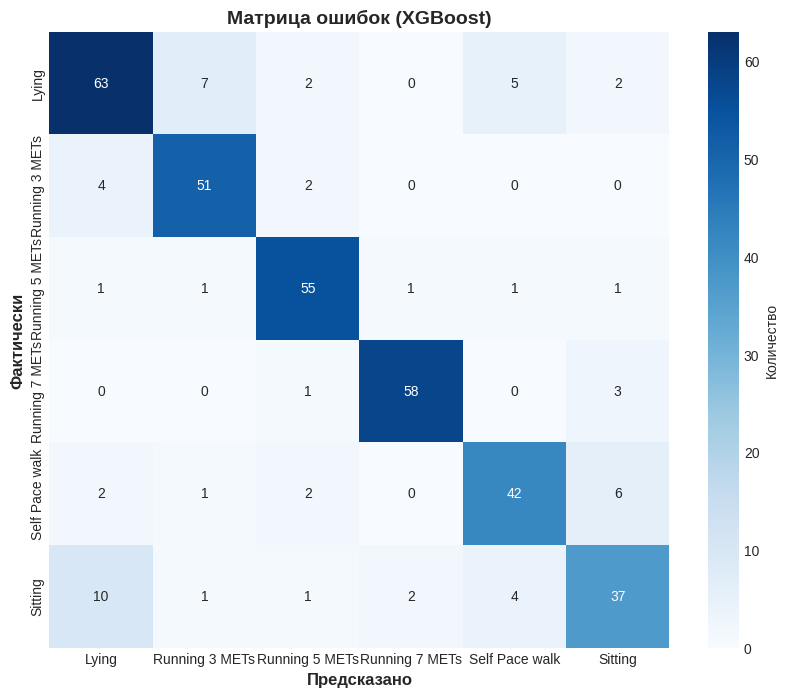


💾 Модель и артефакты сохранены в: experiments/xgboost_optuna/


In [32]:
warnings.filterwarnings('ignore')

feature_names = features.drop(['activity_trimmed'], axis=1).columns.tolist()
inverse_target_mapping = {0: 'Lying', 1: 'Running 3 METs', 2: 'Running 5 METs',3: 'Running 7 METs',4: 'Self Pace walk',5: 'Sitting'}

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Классы: {inverse_target_mapping}")

def train_xgboost(X_train, y_train, best_params, random_state=42):
    """Обучение XGBoost с оптимальными параметрами"""

    model = xgb.XGBClassifier(
        **best_params,
        objective='multi:softprob',
        num_class=len(np.unique(y_train)),
        random_state=random_state,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='mlogloss'
    )

    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_train, y_train, X_test, y_test, inverse_mapping):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("\n" + "="*60)
    print("МЕТРИКИ КАЧЕСТВА")
    print("="*60)

    metrics = {
        'Accuracy': accuracy_score,
        'Precision (macro)': lambda y_true, y_pred: precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': lambda y_true, y_pred: recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)': lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

    results = {}
    for name, func in metrics.items():
        train_score = func(y_train, y_pred_train)
        test_score = func(y_test, y_pred_test)
        results[name] = {'train': train_score, 'test': test_score}
        print(f"{name:25s} | Train: {train_score:.4f} | Test: {test_score:.4f}")

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    print(f"\nCross-Validation F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    # Отчёт по классам
    print("\nClassification Report (Test):")
    target_names = [inverse_mapping[i] for i in sorted(inverse_mapping.keys())]
    print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

    return results, y_pred_test

def plot_feature_importance(model, feature_names, top_n=15, save_path=None):
    """Визуализация важности признаков (gain-based)"""

    # XGBoost предоставляет importance_scores_
    importance = model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance,
        'is_selected': importance > 0.01
    }).sort_values('importance', ascending=False)

    n_selected = importance_df['is_selected'].sum()
    n_total = len(importance_df)

    print("\n" + "="*60)
    print("ВАЖНОСТЬ ПРИЗНАКОВ (XGBoost Gain)")
    print("="*60)
    print(f"Всего признаков: {n_total}")
    print(f"Важных (importance > 0.01): {n_selected}")
    print(f"Доля важных: {n_selected/n_total*100:.1f}%")

    print(f"\nТоп-{min(top_n, n_selected)} важных признаков:")
    for i, row in importance_df.head(top_n).iterrows():
        print(f"  {row['feature']:45s} | {row['importance']:.4f}")

    # Визуализация
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # График 1: Топ признаков
    top_features = importance_df.head(top_n)
    colors = ['#2ecc71' if x else '#95a5a6' for x in top_features['is_selected']]
    axes[0].barh(range(len(top_features)), top_features['importance'], color=colors)
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['feature'], fontsize=9)
    axes[0].set_xlabel('Важность (Gain)', fontsize=11)
    axes[0].set_title(f'Топ-{top_n} признаков', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()

    # График 2: Распределение
    axes[1].hist(importance, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
    axes[1].axvline(x=0.01, color='#e74c3c', linestyle='--', linewidth=2, label='Порог')
    axes[1].set_xlabel('Важность признака', fontsize=11)
    axes[1].set_ylabel('Количество признаков', fontsize=11)
    axes[1].set_title('Распределение важности', fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\nГрафик сохранён: {save_path}")

    plt.show()
    return importance_df

def plot_confusion_matrix(y_true, y_pred, inverse_mapping, save_path=None):
    target_names = [inverse_mapping[i] for i in sorted(inverse_mapping.keys())]
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'label': 'Количество'})
    plt.xlabel('Предсказано', fontsize=12, fontweight='bold')
    plt.ylabel('Фактически', fontsize=12, fontweight='bold')
    plt.title('Матрица ошибок (XGBoost)', fontsize=14, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Матрица сохранена: {save_path}")

    plt.show()

def run_experiment(save_dir='experiments/xgboost_optuna', n_trials=50):
    """Запуск полного эксперимента"""

    model = train_xgboost(X_train, y_train, best_params)

    print("\nОценка качества...")
    metrics, y_pred = evaluate_model(model, X_train, y_train, X_test, y_test, inverse_target_mapping)

    print("\nВизуализация важности признаков...")
    importance_df = plot_feature_importance(
        model, feature_names, top_n=15,
        save_path=f'{save_dir}/feature_importance.png'
    )

    # Матрица ошибок
    plot_confusion_matrix(
        y_test, y_pred, inverse_target_mapping,
        save_path=f'{save_dir}/confusion_matrix.png'
    )

    # 7. Сохранение
    os.makedirs(save_dir, exist_ok=True)
    joblib.dump(model, f'{save_dir}/model_xgboost.joblib')
    joblib.dump(best_params, f'{save_dir}/best_params.joblib')
    joblib.dump(study, f'{save_dir}/optuna_study.joblib')
    print(f"\n💾 Модель и артефакты сохранены в: {save_dir}/")

    return model, metrics, importance_df, study

if __name__ == "__main__":
    model, metrics, importance, study = run_experiment(n_trials=50)

# Схранение

In [22]:
import json

def export_preprocessor_params(preprocessor_path, output_path):
    prep = joblib.load(preprocessor_path)

    params = {
        'mean': prep.scaler.mean_.tolist(),
        'std': prep.scaler.scale_.tolist(),
        'feature_names': prep.feature_names,
        'target_mapping': prep.target_mapping,
        'inverse_target_mapping': {str(k): v for k, v in prep.inverse_target_mapping.items()}
    }

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(params, f, indent=2, ensure_ascii=False)

    print(f"Параметры экспортированы: {output_path}")

# Использование
export_preprocessor_params(
    'models/preprocessor_v1.joblib',
    'models/preprocessor_v1.json'
)

Параметры экспортированы: models/preprocessor_v1.json


In [23]:
!pip install onnx onnxconverter_common onnxmltools onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 21.9 MB/s eta 0:00:00


In [24]:
import onnxmltools
print("Экспорт XGBoost модели в ONNX формат...")

model = joblib.load('experiments/xgboost_optuna/model_xgboost.joblib')
print(f"Модель загружена: {type(model)}")

X_sample = X_train[:1]
n_features = X_sample.shape[1]
print(f"Количество признаков: {n_features}")

print("Конвертация в ONNX...")
onnx_model = onnxmltools.convert_xgboost(
    model,
    initial_types=[('float_input', onnxmltools.convert.common.data_types.FloatTensorType([None, n_features]))],
    target_opset=14
)


os.makedirs('models', exist_ok=True)
with open('models/model_harvardAWData_xgboost.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

model_size_kb = os.path.getsize('models/model_harvardAWData_xgboost.onnx') / 1024
print(f"Модель экспортирована: models/model_harvardAWData_xgboost.onnx")
print(f"Размер: {model_size_kb:.1f} KB")

print("\nЭкспорт завершен!")

Экспорт XGBoost модели в ONNX формат...
Модель загружена: <class 'xgboost.sklearn.XGBClassifier'>
Количество признаков: 16
Конвертация в ONNX...
Модель экспортирована: models/model_harvardAWData_xgboost.onnx
Размер: 5390.0 KB

Экспорт завершен!


In [25]:
import onnxruntime as ort

print("Проверка ONNX модели...")

session = ort.InferenceSession('models/model_harvardAWData_xgboost.onnx')
original_model = joblib.load('experiments/xgboost_optuna/model_xgboost.joblib')
X_test = X_test[:10]
Y_test = y_test[:10]

print(f"\nВходные узлы: {[i.name for i in session.get_inputs()]}")
print(f"Выходные узлы: {[o.name for o in session.get_outputs()]}")

onnx_output = session.run(None, {'float_input': X_test.astype(np.float32)})
print(f"\nФорма выхода ONNX: {onnx_output[0].shape}")
print(f"Тип выхода: {type(onnx_output[0])}")

if len(onnx_output[0].shape) == 1:
    onnx_classes = onnx_output[0].astype(int)
    onnx_proba = None
    print("Формат: Классы (1D массив)")
else:
    onnx_proba = onnx_output[0]
    onnx_classes = np.argmax(onnx_proba, axis=1)
    print("Формат: Вероятности (2D массив)")

orig_pred = original_model.predict(X_test)

print("\n" + "="*60)
print("СРАВНЕНИЕ ПРЕДСКАЗАНИЙ")
print("="*60)
print(f"ONNX предсказания:     {onnx_classes[:10]}")
print(f"Original предсказания: {orig_pred[:10]}")
print(f"real:                  {Y_test}")

if np.array_equal(onnx_classes, orig_pred):
    print("\nВсе предсказания совпадают!")
else:
    mismatches = np.sum(onnx_classes != orig_pred)
    print(f"\nНайдено {mismatches} несовпадений из {len(X_test)}")
    print("   Это может быть из-за различий в реализации XGBoost ↔ ONNX")

if onnx_proba is not None:
    orig_proba = original_model.predict_proba(X_test)
    max_diff = np.max(np.abs(onnx_proba - orig_proba))
    print(f"\nМаксимальная разница в вероятностях: {max_diff:.6f}")
    if max_diff < 0.01:
        print("Вероятности совпадают с высокой точностью!")
    else:
        print("Разница в вероятностях > 1% — проверьте экспорт")

print("\nПроверка завершена!")

Проверка ONNX модели...

Входные узлы: ['float_input']
Выходные узлы: ['label', 'probabilities']

Форма выхода ONNX: (10,)
Тип выхода: <class 'numpy.ndarray'>
ℹФормат: Классы (1D массив)

СРАВНЕНИЕ ПРЕДСКАЗАНИЙ
ONNX предсказания:     [4 2 5 0 2 0 4 1 1 0]
Original предсказания: [4 2 5 0 2 0 4 1 1 0]
real:                  [0 0 5 0 2 0 4 1 1 0]

Все предсказания совпадают!

Проверка завершена!


## пример загрузки препроцессора из json

In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from typing import Dict, List, Tuple, Optional
import os


class PreprocessorLoader:
    """
    Загрузчик препроцессора из JSON-файла
    Позволяет восстановить scaler и target_mapping без joblib
    """

    def __init__(self, json_path: str):
        """
        Parameters
        ----------
        json_path : str
            Путь к JSON-файлу с параметрами препроцессора
        """
        self.json_path = json_path
        self.params = None
        self.scaler = None
        self.target_mapping = None
        self.inverse_target_mapping = None
        self.feature_names = None
        self._loaded = False

    def load(self) -> 'PreprocessorLoader':
        """Загрузка параметров из JSON"""
        with open(self.json_path, 'r', encoding='utf-8') as f:
            self.params = json.load(f)

        # Восстановление StandardScaler
        self.scaler = StandardScaler()
        self.scaler.mean_ = np.array(self.params['mean'])
        self.scaler.scale_ = np.array(self.params['std'])
        self.scaler.n_features_in_ = len(self.params['mean'])
        self.scaler.var_ = self.scaler.scale_ ** 2  # дисперсия

        # Восстановление маппингов
        self.target_mapping = self.params['target_mapping']
        self.inverse_target_mapping = {
            int(k): v for k, v in self.params['inverse_target_mapping'].items()
        }

        # Названия признаков
        self.feature_names = self.params['feature_names']

        self._loaded = True
        print(f"✓ Препроцессор загружен из {self.json_path}")
        print(f"  Признаков: {len(self.feature_names)}")
        print(f"  Классов: {len(self.target_mapping)}")
        return self

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        """
        Трансформация новых данных

        Parameters
        ----------
        df : pd.DataFrame
            Входные данные с признаками

        Returns
        -------
        np.ndarray
            Масштабированная матрица признаков
        """
        if not self._loaded:
            raise RuntimeError("Call load() before transform()")

        # Проверка наличия всех признаков
        missing_cols = [col for col in self.feature_names if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Отсутствуют признаки: {missing_cols}")

        # Выбор признаков в правильном порядке
        X = df[self.feature_names].copy()

        # Заполнение пропусков (0 или медиана - как было при обучении)
        X = X.fillna(0)

        # Масштабирование
        X_scaled = self.scaler.transform(X.values)

        return X_scaled

    def inverse_transform_target(self, y: np.ndarray) -> List[str]:
        """
        Преобразование предсказаний модели в названия активностей

        Parameters
        ----------
        y : np.ndarray
            Предсказания модели (int)

        Returns
        -------
        List[str]
            Названия активностей
        """
        if not self._loaded:
            raise RuntimeError("Call load() before inverse_transform_target()")

        return [self.inverse_target_mapping.get(int(idx), 'Unknown') for idx in y]

    def get_class_names(self) -> List[str]:
        """Возвращает список классов активности"""
        if not self._loaded:
            raise RuntimeError("Call load() first")
        return list(self.target_mapping.keys())

    def get_feature_names(self) -> List[str]:
        """Возвращает список признаков"""
        if not self._loaded:
            raise RuntimeError("Call load() first")
        return self.feature_names.copy()